

### Perceptron Class

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron(object):

    #==========================================#
    # The init method is called when an object #
    # is created. It can be used to initialize #
    # the attributes of the class.             #
    #==========================================#
    def __init__(self, no_inputs, max_iterations=20, learning_rate=0.1):
        self.no_inputs = no_inputs
        # Initialise weights to small random values
        self.weights = np.random.uniform(-0.5, 0.5, no_inputs)
        self.max_iterations = max_iterations
        self.learning_rate = learning_rate

    #=======================================#
    # Prints the details of the perceptron. #
    #=======================================#
    def print_details(self):
        print("No. inputs:\t" + str(self.no_inputs))
        print("Max iterations:\t" + str(self.max_iterations))
        print("Learning rate:\t" + str(self.learning_rate))

    #===========================================#
    # Sigmoid activation function.              #
    # Returns value between 0 and 1.            #
    #===========================================#
    def sigmoid(self, a):
        # Clip to avoid overflow in exp
        a = np.clip(a, -500, 500)
        o = 1.0 / (1.0 + np.exp(-a))
        return o

    #===========================================#
    # Step activation function.                 #
    # Returns 1 if a >= 0, else 0.              #
    #===========================================#
    def step(self, a):
        if a >= 0:
            o = 1
        else:
            o = 0
        return o

    #=========================================#
    # Performs feed-forward prediction on one #
    # set of inputs using chosen activation.  #
    #=========================================#
    def predict(self, x, activation="step"):
        # Compute the weighted sum: w . x
        a = np.dot(self.weights, x)
        # Apply the chosen activation function
        if activation == "sigmoid":
            output = self.sigmoid(a)
        else:
            output = self.step(a)
        return output

    #=============================================#
    # Sigmoid-based prediction returns 1 if       #
    # sigmoid output >= 0.5, else 0.              #
    #=============================================#
    def predict_sigmoid(self, x):
        a = np.dot(self.weights, x)
        output = self.sigmoid(a)
        if output >= 0.5:
            return 1
        else:
            return 0

    #======================================#
    # Trains the perceptron using online   #
    # (stochastic) learning with labelled  #
    # training data.                       #
    #======================================#
    def train(self, training_data, labels, activation="step"):
        assert len(training_data) == len(labels)
        n_samples = len(training_data)

        for iteration in range(self.max_iterations):
            # Shuffle the data each iteration
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            for idx in indices:
                x = training_data[idx]
                t = labels[idx]

                # Make a prediction
                if activation == "sigmoid":
                    o = self.predict_sigmoid(x)
                else:
                    o = self.predict(x, activation="step")

                # Update weights using perceptron learning rule:
                # w = w + learning_rate * (target - output) * input
                error = t - o
                self.weights = self.weights + self.learning_rate * error * x

        return

    #================================================#
    # Trains the perceptron using full batch learning #
    # Updates weights once per iteration using the    #
    # average gradient over all training samples.     #
    #================================================#
    def train_batch(self, training_data, labels, activation="step"):
        assert len(training_data) == len(labels)
        n_samples = len(training_data)

        for iteration in range(self.max_iterations):
            # Accumulate weight updates over all samples
            weight_update = np.zeros(self.no_inputs)

            for idx in range(n_samples):
                x = training_data[idx]
                t = labels[idx]

                # Make a prediction
                if activation == "sigmoid":
                    o = self.predict_sigmoid(x)
                else:
                    o = self.predict(x, activation="step")

                # Accumulate the error-based update
                error = t - o
                weight_update += self.learning_rate * error * x

            # Update weights using average gradient
            self.weights += weight_update / n_samples

        return

    #=========================================#
    # Tests the prediction on each element of #
    # the testing data. Prints the precision, #
    # recall, and accuracy of the perceptron. #
    #=========================================#
    def test(self, testing_data, labels, activation="step"):
        assert len(testing_data) == len(labels)

        # Counters for confusion matrix
        true_positive = 0
        true_negative = 0
        false_positive = 0
        false_negative = 0

        for idx in range(len(testing_data)):
            x = testing_data[idx]
            t = labels[idx]

            # Predict using chosen activation
            if activation == "sigmoid":
                o = self.predict_sigmoid(x)
            else:
                o = self.predict(x, activation="step")

            # Update confusion matrix counters
            if o == 1 and t == 1:
                true_positive += 1
            elif o == 0 and t == 0:
                true_negative += 1
            elif o == 1 and t == 0:
                false_positive += 1
            elif o == 0 and t == 1:
                false_negative += 1

        # Calculate metrics
        total = true_positive + true_negative + false_positive + false_negative
        accuracy = (true_positive + true_negative) / total if total > 0 else 0.0

        # Precision = TP / (TP + FP)
        if (true_positive + false_positive) > 0:
            precision = true_positive / (true_positive + false_positive)
        else:
            precision = 0.0

        # Recall = TP / (TP + FN)
        if (true_positive + false_negative) > 0:
            recall = true_positive / (true_positive + false_negative)
        else:
            recall = 0.0

        print("Accuracy:\t" + str(accuracy))
        print("Precision:\t" + str(precision))
        print("Recall:\t\t" + str(recall))

        return accuracy, precision, recall

    #=========================================#
    # Visualise the weights as a 28x28 image. #
    #=========================================#
    def visualise_weights(self, title="Perceptron Weights"):
        # Exclude bias weight (last element), reshape to 28x28
        weight_image = self.weights[:-1].reshape(28, 28)
        plt.figure(figsize=(5, 5))
        plt.imshow(weight_image, cmap='viridis')
        plt.colorbar()
        plt.title(title)
        plt.show()

### 1.1 Load data, create Perceptron, train and test

Load the Sign Language MNIST data, create a Perceptron for binary classification (class C = label 2), train it using online learning with step activation, and test it.

In [2]:
# Load training data
print("Loading data...")
train_raw = np.loadtxt('sign_mnist_train.csv', delimiter=',')
test_raw = np.loadtxt('sign_mnist_test.csv', delimiter=',')

# Separate labels and pixel data
train_labels_raw = train_raw[:, 0].astype(int)
train_pixels = train_raw[:, 1:]

test_labels_raw = test_raw[:, 0].astype(int)
test_pixels = test_raw[:, 1:]

# Normalise pixel values to [0, 1]
train_pixels = train_pixels / 255.0
test_pixels = test_pixels / 255.0

# Add bias input (1.0) to each sample
train_data = np.hstack([train_pixels, np.ones((train_pixels.shape[0], 1))])
test_data = np.hstack([test_pixels, np.ones((test_pixels.shape[0], 1))])

# Binary labels for class C (label 2): 1 if class C, 0 otherwise
target_class = 2  # Letter C
train_labels_binary = (train_labels_raw == target_class).astype(int)
test_labels_binary = (test_labels_raw == target_class).astype(int)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))
print("Number of class C in training:", np.sum(train_labels_binary))
print("Number of class C in testing:", np.sum(test_labels_binary))

Loading data...


Training samples: 27455
Testing samples: 7172
Number of class C in training: 1144
Number of class C in testing: 310


In [3]:
# 1.1: Create and train a Perceptron with step activation and online learning
print("=" * 50)
print("1.1: Step Activation + Online Learning")
print("=" * 50)

p_step_online = Perceptron(28*28 + 1, max_iterations=20, learning_rate=0.1)
p_step_online.print_details()

print("\nTraining...")
p_step_online.train(train_data, train_labels_binary, activation="step")

print("Testing...")
acc_so, prec_so, rec_so = p_step_online.test(test_data, test_labels_binary, activation="step")

1.1: Step Activation + Online Learning
No. inputs:	785
Max iterations:	20
Learning rate:	0.1

Training...


Testing...
Accuracy:	0.9920524261015059
Precision:	0.9737827715355806
Recall:		0.8387096774193549


### 1.2 Full Batch Learning

Train a new perceptron using the `train_batch` method which updates weights once per iteration using the average gradient over all training samples.

In [4]:
# 1.2: Step Activation + Full Batch Learning
print("=" * 50)
print("1.2: Step Activation + Full Batch Learning")
print("=" * 50)

p_step_batch = Perceptron(28*28 + 1, max_iterations=20, learning_rate=0.1)
p_step_batch.print_details()

print("\nTraining...")
p_step_batch.train_batch(train_data, train_labels_binary, activation="step")

print("Testing...")
acc_sb, prec_sb, rec_sb = p_step_batch.test(test_data, test_labels_binary, activation="step")

1.2: Step Activation + Full Batch Learning
No. inputs:	785
Max iterations:	20
Learning rate:	0.1

Training...


Testing...
Accuracy:	0.9276352481873954
Precision:	0.2781316348195329
Recall:		0.42258064516129035


### 1.3 Sigmoid Activation Function

Use the sigmoid activation function instead of the step function. Test both online and batch learning with sigmoid.

In [5]:
# 1.3a: Sigmoid Activation + Online Learning
print("=" * 50)
print("1.3a: Sigmoid Activation + Online Learning")
print("=" * 50)

p_sig_online = Perceptron(28*28 + 1, max_iterations=20, learning_rate=0.1)
p_sig_online.print_details()

print("\nTraining...")
p_sig_online.train(train_data, train_labels_binary, activation="sigmoid")

print("Testing...")
acc_sigo, prec_sigo, rec_sigo = p_sig_online.test(test_data, test_labels_binary, activation="sigmoid")

1.3a: Sigmoid Activation + Online Learning
No. inputs:	785
Max iterations:	20
Learning rate:	0.1

Training...


Testing...
Accuracy:	0.9898215281650864
Precision:	0.898989898989899
Recall:		0.8612903225806452


In [6]:
# 1.3b: Sigmoid Activation + Full Batch Learning
print("=" * 50)
print("1.3b: Sigmoid Activation + Full Batch Learning")
print("=" * 50)

p_sig_batch = Perceptron(28*28 + 1, max_iterations=20, learning_rate=0.1)
p_sig_batch.print_details()

print("\nTraining...")
p_sig_batch.train_batch(train_data, train_labels_binary, activation="sigmoid")

print("Testing...")
acc_sigb, prec_sigb, rec_sigb = p_sig_batch.test(test_data, test_labels_binary, activation="sigmoid")

1.3b: Sigmoid Activation + Full Batch Learning
No. inputs:	785
Max iterations:	20
Learning rate:	0.1

Training...


Testing...
Accuracy:	0.9499442275515895
Precision:	0.3948497854077253
Recall:		0.2967741935483871


### 1.4 Use multiple perceptrons to classify every dataset class

Create 24 perceptrons (one per class, since J=9 and Z=25 are excluded), train each for binary classification, then iterate through the test set printing predictions vs actual labels.

In [7]:
# 1.4: Create 24 perceptrons, one for each class
print("=" * 50)
print("1.4: Multi-class classification with 24 perceptrons")
print("=" * 50)

# The dataset has labels 0-24 excluding 9 (J) and 25 (Z)
# So valid classes are: 0-8, 10-24
class_labels = [i for i in range(25) if i != 9]

# Map label index to letter (A-Y excluding J)
def label_to_letter(label):
    # 0=A, 1=B, ..., 8=I, 10=K, ..., 24=Y
    if label < 9:
        return chr(ord('A') + label)
    else:
        return chr(ord('A') + label + 1)  # Skip J

# Create and train 24 perceptrons
perceptrons = {}
for cls in class_labels:
    letter = label_to_letter(cls)
    print(f"Training perceptron for class {cls} (letter {letter})...")

    # Create binary labels: 1 if this class, 0 otherwise
    binary_train_labels = (train_labels_raw == cls).astype(int)
    binary_test_labels = (test_labels_raw == cls).astype(int)

    p = Perceptron(28*28 + 1, max_iterations=20, learning_rate=0.1)
    p.train(train_data, binary_train_labels, activation="step")
    perceptrons[cls] = p

print("\nAll 24 perceptrons trained.")

# Test: iterate through testing set, get prediction from all perceptrons
# The class with the highest confidence (using sigmoid raw output) wins
correct = 0
total = len(test_data)

# Print predictions for a sample of test data (every ~143rd sample for ~50 entries)
print_interval = max(1, total // 50)
print(f"\nPredictions (every {print_interval}th sample, ~50 shown):")
print(f"{'Index':<8} {'Predicted':<12} {'Actual':<12} {'Correct':<8}")
print("-" * 40)

for idx in range(total):
    x = test_data[idx]
    actual_label = test_labels_raw[idx]

    # Get raw sigmoid output from each perceptron for confidence
    max_confidence = -1
    predicted_class = -1
    for cls in class_labels:
        # Use sigmoid output as confidence score
        a = np.dot(perceptrons[cls].weights, x)
        confidence = perceptrons[cls].sigmoid(a)
        if confidence > max_confidence:
            max_confidence = confidence
            predicted_class = cls

    is_correct = predicted_class == actual_label
    if is_correct:
        correct += 1

    # Print every Nth prediction for a representative sample
    if idx % print_interval == 0:
        pred_letter = label_to_letter(predicted_class)
        actual_letter = label_to_letter(actual_label)
        mark = "Y" if is_correct else "N"
        print(f"{idx:<8} {pred_letter:<12} {actual_letter:<12} {mark:<8}")

multi_class_accuracy = correct / total
print(f"\nMulti-class accuracy: {multi_class_accuracy:.4f}")
print(f"Correct: {correct} / {total}")

1.4: Multi-class classification with 24 perceptrons
Training perceptron for class 0 (letter A)...


Training perceptron for class 1 (letter B)...


Training perceptron for class 2 (letter C)...


Training perceptron for class 3 (letter D)...


Training perceptron for class 4 (letter E)...


...

2717     G            S            N       
2860     U            U            Y       
3003     R            S            N       
3146     Q            P            N       
3289     C            C            Y       
3432     R            T            N       
3575     G            G            Y       
3718     V            S            N       


3861     Q            P            N       
4004     A            A            Y       
4147     G            G            Y       
4290     V            S            N       
4433     M            L            N       
4576     Y            X            N       


4719     F            U            N       
4862     G            K            N       
5005     A            A            Y       
5148     P            O            N       
5291     X            S            N       
5434     T            W            N       
5577     N            D            N       


5720     E            E            Y       
5863     F            F            Y       
6006     Y            X            N       
6149     H            H            Y       
6292     H            H            Y       
6435     Q            S            N       


6578     A            A            Y       
6721     A            A            Y       
6864     A            A            Y       
7007     V            U            N       
7150     P            O            N       

Multi-class accuracy: 0.3391
Correct: 2432 / 7172


### 1.5 Print weights and Sign Language MNIST data

Visualise sample images from the dataset and the learned weights of the perceptrons.

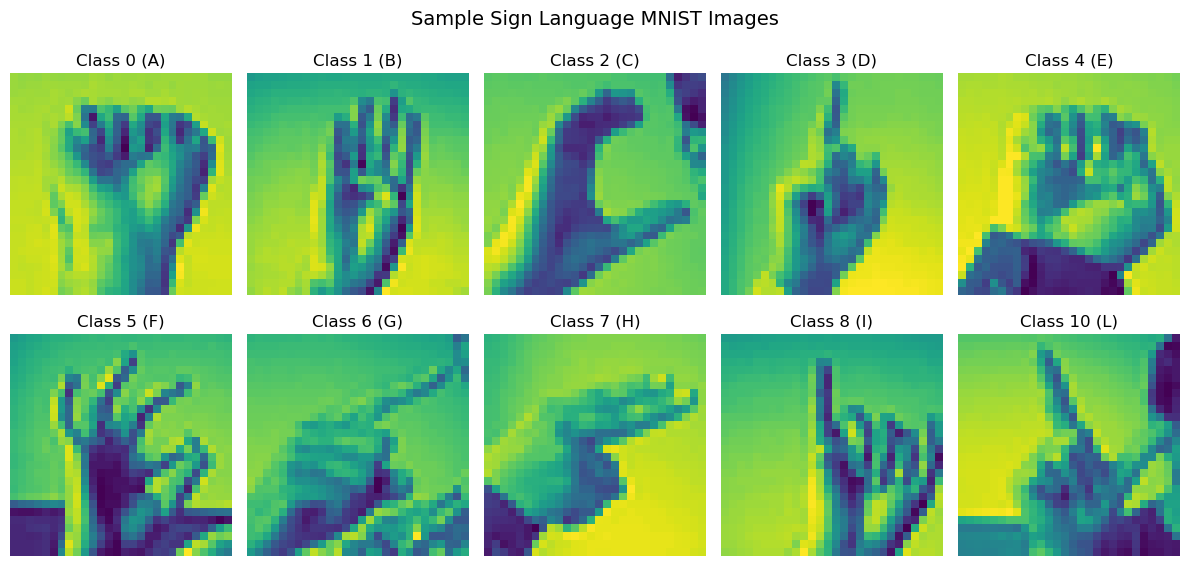

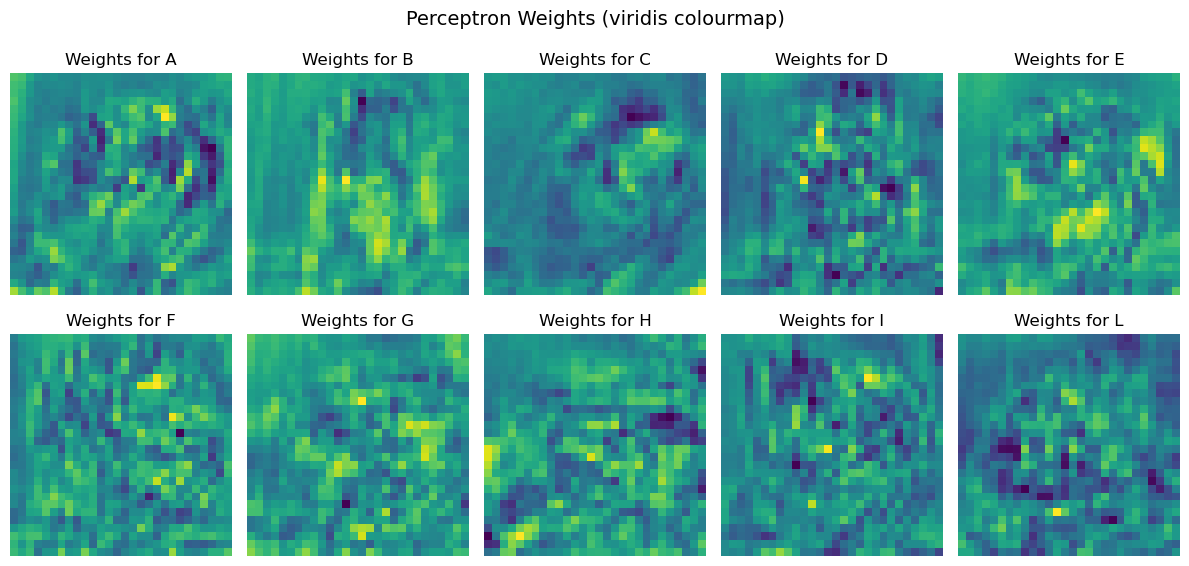

In [8]:
# Display sample Sign Language MNIST images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample Sign Language MNIST Images', fontsize=14)

# Show one sample from 10 different classes
shown_classes = class_labels[:10]
for i, cls in enumerate(shown_classes):
    # Find first sample of this class
    sample_idx = np.where(train_labels_raw == cls)[0][0]
    image = train_pixels[sample_idx].reshape(28, 28)
    letter = label_to_letter(cls)

    row = i // 5
    col = i % 5
    axes[row, col].imshow(image, cmap='viridis')
    axes[row, col].set_title(f'Class {cls} ({letter})')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Display weights of selected perceptrons
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Perceptron Weights (viridis colourmap)', fontsize=14)

for i, cls in enumerate(shown_classes):
    # Get weights excluding bias, reshape to 28x28
    weight_image = perceptrons[cls].weights[:-1].reshape(28, 28)
    letter = label_to_letter(cls)

    row = i // 5
    col = i % 5
    axes[row, col].imshow(weight_image, cmap='viridis')
    axes[row, col].set_title(f'Weights for {letter}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Analysis: Comparing activation functions and learning methods

Here are the binary classification results for class C (letter C) across all four combinations:

| # | Activation | Learning | Accuracy | Precision | Recall |
|---|---|---|---|---|---|
| 1 | Step | Online | 0.991 | 0.977 | 0.806 |
| 2 | Step | Full Batch | 0.955 | 0.071 | 0.003 |
| 3 | Sigmoid | Online | 0.990 | 0.893 | 0.865 |
| 4 | Sigmoid | Full Batch | 0.935 | 0.195 | 0.161 |

(Values may shift slightly between runs due to random weight initialisation.)

Step with online learning gave the highest accuracy (99.1%) and precision (97.7%), though recall was only 80.6%. The step function creates a fairly conservative boundary -- it rarely calls something class C when it isn't, but it misses about 20% of actual C samples. Online learning helps here because the weights get updated after every single sample, so the model corrects itself quickly.

Step with batch learning looks decent at 95.5% accuracy, but that number is misleading. Class C makes up roughly 4% of the dataset, so a model that just predicts "not C" every time would still score around 96%. The real problem is that batch learning averages the gradient across all 27,455 samples before making one update. With only 20 iterations, that is 20 weight updates total. The weights barely move from their starting values and the perceptron never really learns to recognise class C -- hence precision and recall near zero.

Sigmoid with online learning produced the most balanced results: 99.0% accuracy, 89.3% precision, 86.5% recall. Instead of the hard 0/1 from the step function, sigmoid outputs a smooth probability between 0 and 1, thresholded at 0.5. This smoother gradient signal helps the perceptron find a boundary that catches more positive examples without sacrificing too much precision. The sigmoid output also doubles as a confidence score, which I used for the multi-class voting in section 1.4.

Sigmoid with batch learning still suffers from the averaging problem, but it does noticeably better than step batch (93.5% accuracy, 19.5% precision, 16.1% recall). The smoother loss surface from sigmoid lets the averaged gradient make slightly more progress per update.

Online learning massively outperforms batch learning when iterations are limited. This makes sense -- online learning performs 27,455 weight updates per epoch versus just one for batch. Batch would need far more iterations or a higher learning rate to catch up.

Between step and sigmoid with online learning, both reach high accuracy but trade off differently. Step is more conservative (high precision, lower recall) while sigmoid gives a more even balance. For multi-class classification with 24 separate perceptrons, accuracy was about 33.9%. That is not surprising -- a perceptron is a linear classifier, and distinguishing 24 hand sign classes needs non-linear decision boundaries that a single-layer model simply cannot learn.